In [143]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style="darkgrid", font="serif") #TODO: fix with actual thesis font

matrix_path = "/home/mengelsl/MA-bench-framework/matrices/binary_spmc"

def get_mb(matrix_name, symmetric):
    if symmetric:
        matrix_name = "symmetric/" + matrix_name
    else:
        matrix_name = "unsymmetric/" + matrix_name

    f_path = os.path.join(matrix_path, matrix_name)
    try:
        return round(os.path.getsize(f_path) / (1024**2))
    except: return None

main_folder = {
    "Native": "/home/mengelsl/MA-bench-framework/outputs/krylov/native/",
    "SME": "/home/mengelsl/MA-bench-framework/outputs/krylov/sme/",
    "SME+SEV": "/home/mengelsl/MA-bench-framework/outputs/krylov/sev/",
    "Native_interleave": "/home/mengelsl/MA-bench-framework/outputs/krylov/native_interleave/",
    "SME_interleave": "/home/mengelsl/MA-bench-framework/outputs/krylov/sme_interleave/",
    "SME+SEV_interleave": "/home/mengelsl/MA-bench-framework/outputs/krylov/sev_interleave/",
}

In [144]:
results_list = []

for label, path in main_folder.items():
    f_path = os.path.join(path, "results.csv")
    print(f"Checking for {label} at {f_path}...")
    if os.path.exists(f_path):
        df = pd.read_csv(f_path)
        print(f"Loaded {len(df)} rows for {label}.")
        df["Mode"] = label.split("_interleave")[0]
        df["VM_NUMA"] = "interleave" if "interleave" in label else "strict"
        results_list.append(df)

df_raw = pd.concat(results_list, ignore_index=True)
df_raw.rename(columns={"Process_NUMA_Policy": "Process_NUMA"}, inplace=True)

Checking for Native at /home/mengelsl/MA-bench-framework/outputs/krylov/native/results.csv...
Loaded 2400 rows for Native.
Checking for SME at /home/mengelsl/MA-bench-framework/outputs/krylov/sme/results.csv...
Loaded 2400 rows for SME.
Checking for SME+SEV at /home/mengelsl/MA-bench-framework/outputs/krylov/sev/results.csv...
Loaded 2400 rows for SME+SEV.
Checking for Native_interleave at /home/mengelsl/MA-bench-framework/outputs/krylov/native_interleave/results.csv...
Loaded 2400 rows for Native_interleave.
Checking for SME_interleave at /home/mengelsl/MA-bench-framework/outputs/krylov/sme_interleave/results.csv...
Loaded 2400 rows for SME_interleave.
Checking for SME+SEV_interleave at /home/mengelsl/MA-bench-framework/outputs/krylov/sev_interleave/results.csv...
Loaded 2400 rows for SME+SEV_interleave.


In [145]:
config_cols_raw = ["Mode", "Matrix", "Cores", "Process_NUMA", "VM_NUMA", "Algo", "Arg1", "Arg2", "Arg3", "N_Ops"]
metric_cols_raw = [ "SpMV_Time", "Mgmt_Time", "Perf_Cycles", "Perf_Instructions", "Perf_CacheMisses", "Perf_dTLBMisses" ]

config_drop_counts = []

def iqr_mark_outliers(group):
    group = group.copy()
    group_drops = 0

    for col in metric_cols_raw:
        if col not in group.columns:
            continue
        
        data = pd.to_numeric(group[col], errors="coerce")
        valid = data.dropna()
        
        if valid.empty:
            continue
        
        q1, q3 = valid.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        
        mask = (data >= lower) & (data <= upper)
        
        group_drops += (~mask & data.notna()).sum()
        
        # Mark outliers as NaN
        group.loc[~mask, col] = np.nan

    config_drop_counts.append(group_drops)
    return group

df_clean = df_raw.groupby(config_cols_raw).apply(iqr_mark_outliers, include_groups=False).reset_index()

total_points_removed = np.sum(config_drop_counts)

print(f"Total metric data points: {len(df_raw) * len(metric_cols_raw)}")
print(f"Total data points removed: {total_points_removed}")
print(f"Data points removed (%): {total_points_removed / (len(df_raw) * len(metric_cols_raw)) * 100:.2f}%")

Total metric data points: 86400
Total data points removed: 2608
Data points removed (%): 3.02%


In [146]:
def compute_cv_per_mode(df, config_cols_raw, metrics):
    stats = (
        df
        .groupby(config_cols_raw)[metrics]
        .agg(["mean", "std"])
    )
    
    cv = stats.xs("std", level=1, axis=1) / stats.xs("mean", level=1, axis=1)

    # Aggregate over Mode (first level)
    cv_mode = cv.groupby(level=0).mean()

    cv_mode.fillna(0, inplace=True)
    
    return cv_mode

cv_raw_mode = compute_cv_per_mode(df_raw, config_cols_raw, metric_cols_raw)
cv_clean_mode = compute_cv_per_mode(df_clean, config_cols_raw, metric_cols_raw)

# Print the values displayed in the heatmaps
print("CV (Raw Data) per Mode:")
print(cv_raw_mode.round(2).to_string())
print("\nCV (IQR Cleaned Data) per Mode:")
print(cv_clean_mode.round(2).to_string())

CV (Raw Data) per Mode:
         SpMV_Time  Mgmt_Time  Perf_Cycles  Perf_Instructions  Perf_CacheMisses  Perf_dTLBMisses
Mode                                                                                            
Native         0.0        0.0          0.0                0.0              0.01             0.08
SME            0.0        0.0          0.0                0.0              0.01             0.05
SME+SEV        0.0        0.0          0.0                0.0              0.01             0.07

CV (IQR Cleaned Data) per Mode:
         SpMV_Time  Mgmt_Time  Perf_Cycles  Perf_Instructions  Perf_CacheMisses  Perf_dTLBMisses
Mode                                                                                            
Native         0.0        0.0          0.0                0.0              0.01             0.07
SME            0.0        0.0          0.0                0.0              0.01             0.05
SME+SEV        0.0        0.0          0.0                0.0         

In [147]:
df = df_clean.groupby(config_cols_raw)[metric_cols_raw].median().reset_index()

#Explicit filter as funnily "bicgstab" contains "cg" but is not symmetric.
df["Symmetric"] = df["Algo"].apply(lambda x: ("cg" in x or "lanczos" in x) and "bicg" not in x)
df['MB'] = df.apply(lambda row: get_mb(row['Matrix'], row['Symmetric']), axis=1).astype('Int64')
df["Matrix"] = df["Matrix"].apply(lambda x: x.split(".bin")[0]) 
df["Perf_IPC"] = df['Perf_Instructions'] / df['Perf_Cycles']
df["Time_per_op"] = df["SpMV_Time"] / df["N_Ops"]

metric_cols = metric_cols_raw + ["Perf_IPC", "Time_per_op"]

df.head()

,Mode,Matrix,Cores,Process_NUMA,VM_NUMA,Algo,Arg1,Arg2,Arg3,N_Ops,SpMV_Time,Mgmt_Time,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses,Symmetric,MB,Perf_IPC,Time_per_op
0,Native,Bump2911,1,interleave,interleave,cg,159,0,0,159,8.468542,1.332634,3.561613e+10,1.536218e+11,58302643.0,533281.0,True,1473,4.313265,0.053261
1,Native,Bump2911,1,interleave,interleave,lanczos,11,2,10,106,5.687622,3.093740,3.147399e+10,1.198801e+11,37869017.0,257503.0,True,1473,3.808863,0.053657
2,Native,Bump2911,1,interleave,strict,cg,159,0,0,159,8.800064,1.387741,3.701111e+10,1.536218e+11,58115339.0,516729.0,True,1473,4.150694,0.055346
3,Native,Bump2911,1,interleave,strict,lanczos,11,2,10,106,5.879885,3.061235,3.208136e+10,1.198801e+11,37515727.0,247792.0,True,1473,3.736755,0.055471
4,Native,Bump2911,1,membind,interleave,cg,159,0,0,159,8.458861,1.331657,3.557956e+10,1.536218e+11,58030389.0,504352.5,True,1473,4.317698,0.053200


<Axes: xlabel='VM_NUMA', ylabel='Time_per_op'>

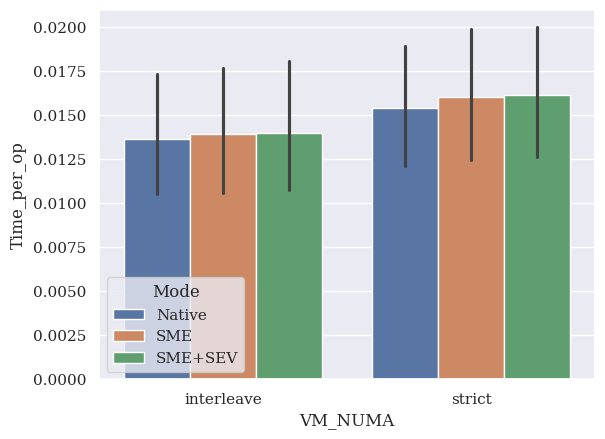

In [148]:
sns.barplot(data=df, x="VM_NUMA", y="Time_per_op", hue="Mode")

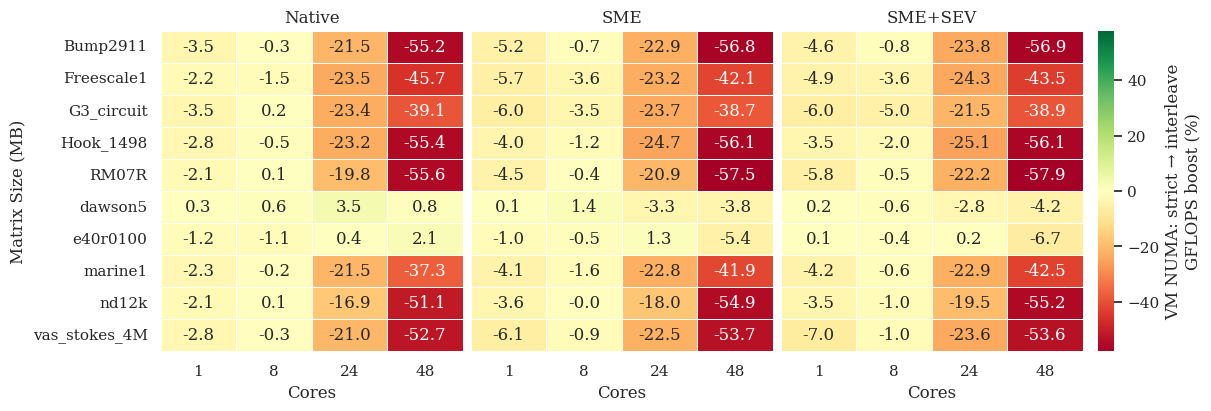

In [149]:
# VM_NUMA boost: interleave vs strict
heat_df = (
	df.pivot_table(
		index=["Mode", "Algo", "Matrix", "Cores", "Process_NUMA"],
		columns="VM_NUMA",
		values="Time_per_op",
		aggfunc="mean"
	)
	.dropna(subset=["interleave", "strict"])
	.reset_index()
)

heat_df["Boost_pct"] = (heat_df["interleave"] - heat_df["strict"]) / heat_df["strict"] * 100

# Per-mode cell values (MB, Cores, Mode)
mode_cell = (
	heat_df.groupby(["Matrix", "Cores", "Mode"], as_index=False)["Boost_pct"]
	.mean()
)

mode_order = ["Native", "SME", "SME+SEV"]
modes = [m for m in mode_order if m in mode_cell["Mode"].unique()]

vabs = mode_cell["Boost_pct"].abs().max()
fig, axes = plt.subplots(1, len(modes), figsize=(12, 4), constrained_layout=True, sharey=True)

if len(modes) == 1:
	axes = [axes]

for i, mode in enumerate(modes):
	p_mode = (
		mode_cell[mode_cell["Mode"] == mode]
		.pivot(index="Matrix", columns="Cores", values="Boost_pct")
		.sort_index()
	)
	p_mode = p_mode.reindex(sorted(p_mode.columns), axis=1)

	sns.heatmap(
		p_mode,
		ax=axes[i],
		cmap="RdYlGn",
		center=0,
		vmin=-vabs,
		vmax=vabs,
		annot=True,
		fmt=".1f",
		linewidths=0.4,
		linecolor="white",
		cbar=(i == len(modes) - 1),
		cbar_kws={"label": "VM NUMA: strict → interleave\nGFLOPS boost (%)"} if i == len(modes) - 1 else None
	)

	axes[i].set_title(mode)
	axes[i].set_xlabel("Cores")
	if i == 0:
		axes[i].set_ylabel("Matrix Size (MB)")
	else:
		axes[i].set_ylabel("")
		axes[i].tick_params(axis="y", left=False, labelleft=False)

plt.show()

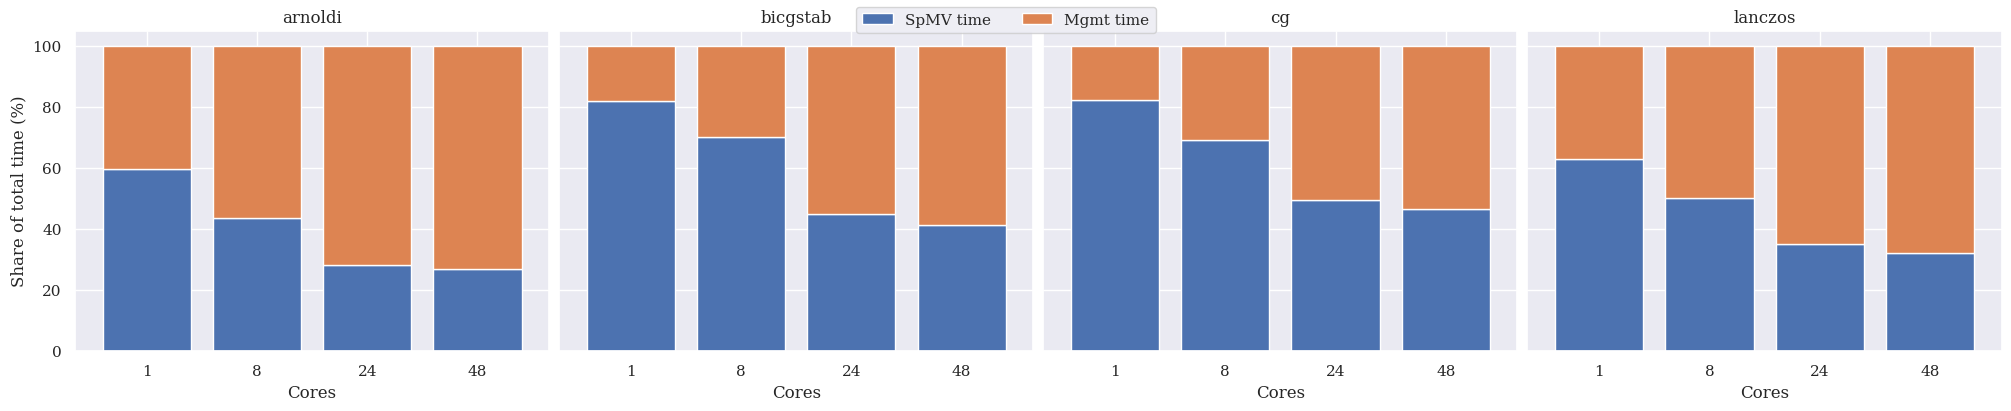

In [164]:
time_cols = ["SpMV_Time", "Mgmt_Time"]

time_share = (
	df.groupby(["Algo", "Cores"])[time_cols]
	.mean()
	.sort_index()
)

time_share_pct = time_share.div(time_share.sum(axis=1), axis=0) * 100

algos = time_share_pct.index.get_level_values("Algo").unique()

fig, axes = plt.subplots(1, len(algos), figsize=(5 * len(algos), 4), sharey=True, constrained_layout=True)
if len(algos) == 1:
	axes = [axes]

for ax, algo in zip(axes, algos):
	plot_df = time_share_pct.xs(algo, level="Algo")
	plot_df.plot(
		kind="bar",
		stacked=True,
		ax=ax,
		color=["#4C72B0", "#DD8452"],
		width=0.8,
		legend=False,
	)
	ax.set_title(algo)
	ax.set_xlabel("Cores")
	ax.tick_params(axis="x", rotation=0)

axes[0].set_ylabel("Share of total time (%)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["SpMV time", "Mgmt time"], title=None, loc="upper center", ncol=2)
plt.show()

In [150]:
merge_cols = [c for c in config_cols_raw if c != "Mode"]

df_native = df[df['Mode'] == 'Native'].copy()
df_other = df[df['Mode'] != 'Native'].copy()

cols_to_keep = merge_cols + metric_cols

df_merged = df_other.merge(
    df_native[cols_to_keep], # Filter here!
    on=merge_cols,
    suffixes=('', '_native')
)
result = df_merged.copy()

for m in metric_cols:
    native_col = f"{m}_native"
    
    # Create the percentage colun
    result[f"{m}_pct"] = np.where(
        df_merged[native_col] != 0,
        (df_merged[m] - df_merged[native_col]) / df_merged[native_col] * 100,
        np.nan
    )
    
    result = result.drop(columns=[native_col, m])


overhead_df = result

Text(0, 0.5, '')

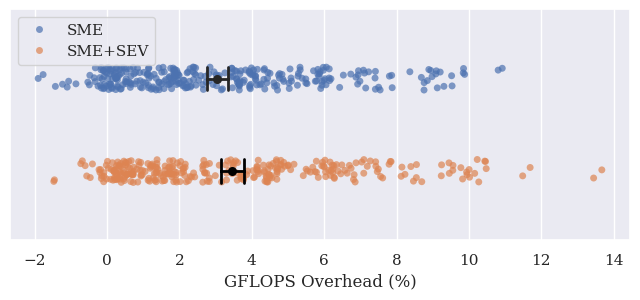

In [151]:
DODGE_VAL = 0.4 

plt.figure(figsize=(8, 3))
sns.pointplot(
    data=overhead_df, 
    x="Time_per_op_pct", 
    hue="Mode", 
    dodge=DODGE_VAL, 
    linestyle=None,
    markersize=5,        
    linewidth=2,             
    capsize=0.1,
    palette="dark:black",
	legend=False,
	zorder=2
)

ax = sns.stripplot(
    data=overhead_df, 
    x="Time_per_op_pct", 
    hue="Mode", 
    dodge=DODGE_VAL,   
    alpha=0.7,
	zorder=1
)

plt.legend(title=None, loc='upper left')
plt.xlabel("GFLOPS Overhead (%)")
plt.ylabel("")

In [152]:
overhead_df.groupby("Mode")["Time_per_op_pct"].aggregate(['mean', 'median'])

,mean,median
Mode,,
SME,3.050856,2.382616
SME+SEV,3.465979,2.723153


→ Algo:
Mode      SME  SME+SEV
Algo                  
arnoldi   3.1      3.5
bicgstab  3.3      3.6
cg        2.9      3.4
lanczos   2.9      3.4
------------------------------------------------------------
→ VM NUMA:
Mode        SME  SME+SEV
VM_NUMA                 
interleave  2.1      2.3
strict      4.0      4.7
------------------------------------------------------------
→ Cores:
Mode   SME  SME+SEV
Cores              
1      3.3      4.0
8      1.1      1.2
24     3.6      3.8
48     4.3      4.9
------------------------------------------------------------


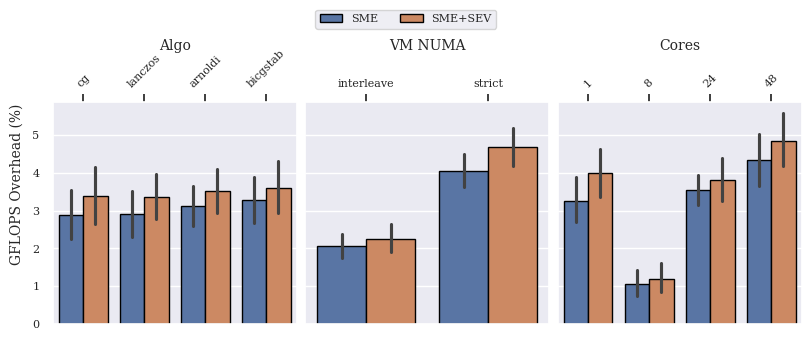

In [153]:
def plot_metric_by_dimensions(metric, metric_legend_name, top):
    all_dims = ['Algo','VM_NUMA', "Cores"] 

    fig, axes = plt.subplots( nrows=1, ncols=len(all_dims), figsize=(8, 3), constrained_layout=True, sharey=True) 

    fig.supylabel(f"{metric_legend_name} Overhead (%)", fontsize=10)
    for ax, a in zip(axes, all_dims):
        sns.barplot( data=overhead_df, x=a, y=metric, hue='Mode', errorbar=("ci",95), edgecolor='black', ax=ax)

        if a=="Matrix":
            ax.set_title("Matrix Size",y=1.2, fontsize=9)
        else:
            ax.set_title(a.replace("_", " "),y=1.2, fontsize=10)
        ax.set_ylabel("")
        ax.set_xlabel("")
        rotation = 0 if a in ['VM_NUMA', 'Process_NUMA'] else 45
        ax.tick_params(axis='x', rotation=rotation, labelsize=8)
        if top:
            ax.xaxis.set_ticks_position('top')
            ax.xaxis.set_label_position('top')
        else:
            ax.xaxis.set_ticks_position('bottom')
            ax.xaxis.set_label_position('bottom')
        ax.tick_params(axis='y', labelsize=8)
        ax.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=8)

    for dim in all_dims:
        print(f"→ {dim.replace('_', ' ')}:")
        summary = (overhead_df.groupby([dim, 'Mode'])[metric]
                   .mean()
                   .round(2)
                   .reset_index())
        
        summary_pivot = summary.pivot(index=dim, columns='Mode', values=metric)
        
        print(summary_pivot.to_string(float_format="{:.1f}".format))
        print("-" * 60)

plot_metric_by_dimensions("Time_per_op_pct", "GFLOPS", top=True)

/tmp/ipykernel_1479547/145704322.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1479547/145704322.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha="right")


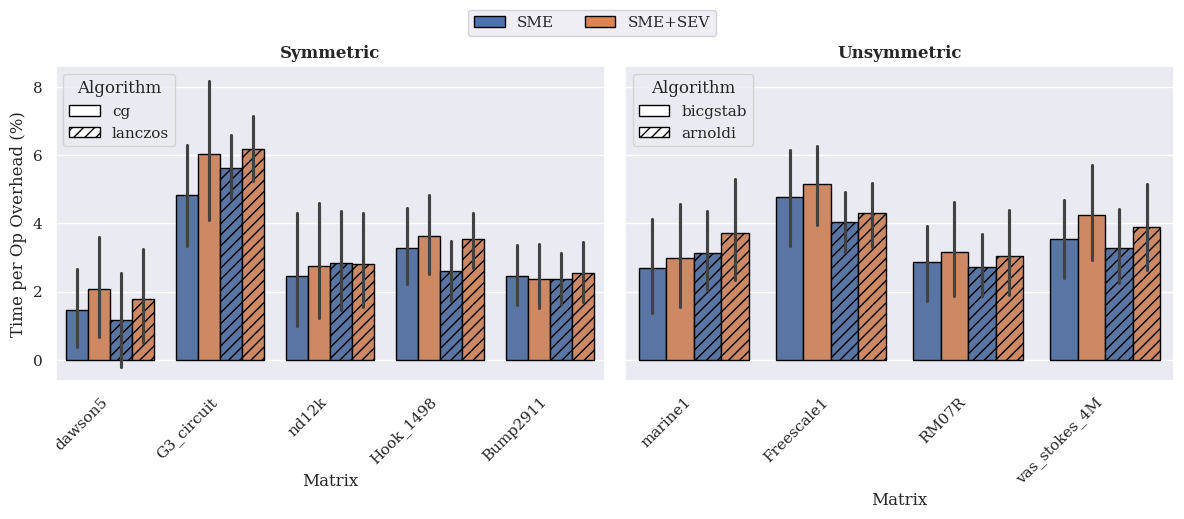

In [158]:
sym_algo_order = ["cg", "lanczos"]
unsym_algo_order = ["bicgstab", "arnoldi"]
algo_patterns = {"cg": "", "lanczos": "///", "bicgstab": "", "arnoldi": "///"}
matrix_order = [
'dawson5', 'G3_circuit', 'nd12k', 'Hook_1498',
'Bump2911', 'e40r0100.bin', 'marine1', 'Freescale1',
'RM07R', 'vas_stokes_4M'
]

# Map colors to Mode (default seaborn colors)
default_colors = sns.color_palette(n_colors=2)
modes_palette = {"SME": default_colors[0], "SME+SEV": default_colors[1]}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for idx, (is_symmetric, title) in enumerate([(True, "Symmetric"), (False, "Unsymmetric")]):
    sub = overhead_df[overhead_df["Symmetric"] == is_symmetric].copy()

    sub["Group"] = sub["Algo"] + " + " + sub["Mode"]
    
    current_algos = sym_algo_order if is_symmetric else unsym_algo_order
    hue_order = []
    for algo in current_algos:
        for mode in ["SME", "SME+SEV"]:
            hue_order.append(f"{algo} + {mode}")

    sns.barplot(
        data=sub,
        x="Matrix",
        y="Time_per_op_pct",
        hue="Group",
        hue_order=hue_order,
        order=[m for m in matrix_order if m in sub["Matrix"].unique()],
        palette=[modes_palette[s.split(" + ")[1]] for s in hue_order],
        errorbar=("ci", 95),
        ax=axes[idx]
    )

	#Hatching by Algorithm
    for container, group_label in zip(axes[idx].containers, hue_order):
        algo_name = group_label.split(" + ")[0].lower()
        pattern = algo_patterns.get(algo_name, "")
        
        for bar in container:
            bar.set_hatch(pattern)
            bar.set_edgecolor("black")

    axes[idx].set_title(f"{title}", fontweight='bold')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha="right")
    axes[idx].get_legend().remove()

    if idx == 0:
        axes[idx].set_ylabel("Time per Op Overhead (%)")
    else:
        axes[idx].set_ylabel("")
        axes[idx].tick_params(axis="y", labelleft=False)

    algo_handles = [
        Patch(facecolor="white", edgecolor="black", hatch=algo_patterns.get(a.lower(), ""), label=a) 
        for a in current_algos
    ]
    axes[idx].legend(handles=algo_handles, title="Algorithm", loc="upper left")

# --- 4. Global Legend for Colors (Modes) ---
mode_handles = [Patch(facecolor=modes_palette[m], edgecolor="black", label=m) for m in ["SME", "SME+SEV"]]
fig.legend(handles=mode_handles, title=None, loc="upper center", 
           bbox_to_anchor=(0.5, 1.05), ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
#average overhead difference per configuration depending on algorithm

# Average deviation between Process_NUMA configs (interleave vs membind) for SpMV_GFLOPS
pair_cols = ["Mode", "Matrix", "Cores", "VM_NUMA", "Process_NUMA"]

base_proc, compare_proc = "bicgstab","arnoldi"

proc_cmp = (
	overhead_df[overhead_df["Algo"].isin([base_proc, compare_proc])].pivot_table(
		index=pair_cols,
		columns="Algo",
		values="Time_per_op_pct",
		aggfunc="mean"
	)
	.dropna(subset=[base_proc, compare_proc])
	.reset_index()
)

proc_cmp["Deviation_pct"] = (
	(proc_cmp[compare_proc] - proc_cmp[base_proc]) / proc_cmp[base_proc] * 100
)
proc_cmp["Abs_Deviation_pct"] = proc_cmp["Deviation_pct"].abs()

print(f"Average deviation ({compare_proc} vs {base_proc}): {proc_cmp['Deviation_pct'].median():.4f}%")
print(f"Average absolute deviation: {proc_cmp['Abs_Deviation_pct'].median():.4f}%")

print("\nBy mode:")
print(
	proc_cmp.groupby("Mode")[["Deviation_pct", "Abs_Deviation_pct"]]
	.median()
	.round(3)
)

Average deviation (arnoldi vs bicgstab): -6.9567%
Average absolute deviation: 16.6985%

By mode:
Algo     Deviation_pct  Abs_Deviation_pct
Mode                                     
SME             -7.111             17.553
SME+SEV         -6.919             16.334
